# plotting results

FFDI results as changes


In [1]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime



In [6]:
from dask.distributed import Client
import dask

# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

#cluster = LocalCluster(
#    n_workers=28,          # Number of workers
#    threads_per_worker=1 #Threads per worker
#    #memory_limit='8GB' # Memory limit per each worker commented out
#)
#client = Client(cluster)

client = Client()
client

2025-09-03 21:04:20,103 - distributed.preloading - INFO - Creating preload: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py
2025-09-03 21:04:20,107 - distributed.utils - INFO - Reload module schedplugin from .py file
2025-09-03 21:04:20,147 - distributed.preloading - INFO - Import preload module: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py


Modifying workers


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/gadi-cpu-bdw-0033.gadi.nci.org.au/22936/proxy/8787/status,
Dashboard: /node/gadi-cpu-bdw-0033.gadi.nci.org.au/22936/proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39593,Workers: 7
Dashboard: /node/gadi-cpu-bdw-0033.gadi.nci.org.au/22936/proxy/8787/status,Total threads: 7
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32945,Total threads: 1
Dashboard: /node/gadi-cpu-bdw-0033.gadi.nci.org.au/22936/proxy/45617/status,Memory: 0 B
Nanny: tcp://127.0.0.1:33613,


In [7]:
# parameters
dirstore='sa_2090'

## modules

In [8]:
def plot_4(SM1,SM2,SM3,ivar,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    cb1='coolwarm'

    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1); SM1.sel(season=id[ivar]).plot(levels=lev,cmap=cb,extend='max')
    plt.title('2025 '+id[ivar])
    
    plt.subplot(2,2,2); SM2.sel(season=id[ivar]).plot(levels=lev,cmap=cb,extend='max')
    plt.title('2050 '+id[ivar])
    plt.subplot(2,2,3); SM3.sel(season=id[ivar]).plot(levels=lev,cmap=cb,extend='max')
    plt.title('2090 '+id[ivar])
    plt.subplot(2,2,4); (SM3.sel(season=id[ivar]) - SM1.sel(season=id[ivar])).plot(levels=10,cmap=cb1,extend='both')
    plt.title('2090 - 2025 '+id[ivar])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

def plot_2(SM1,SM2,SM3,ivar,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    cb1='coolwarm'

    plt.figure(figsize=(8,4.5))
    plt.subplot(1,2,1); (SM2.sel(season=id[ivar]) - SM1.sel(season=id[ivar])).plot(levels=lev,cmap=cb1,extend='both')
    plt.title('2050s - 2025s ')
    
    plt.subplot(1,2,2); (SM3.sel(season=id[ivar]) - SM1.sel(season=id[ivar])).plot(levels=lev,cmap=cb1,extend='both')
    plt.title('2090s - 2025s ')
# Add global title
    plt.suptitle(tit+ id[ivar])
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

# relative change
def plot_2a(SM1,SM2,SM3,ivar,ndim,id,lev,tit,fname='tmp.png'):
    cb1='plasma'
#    cb1='coolwarm'

    plt.figure(figsize=(8,4.5))
#    plt.subplot(1,2,1); (SM2.sum(dim='season')/ 365.).plot(levels=lev,cmap=cb1,extend='both')
    plt.subplot(1,2,1); (SM2.sum(dim='season')/ SM1.sum(dim='season')).plot(levels=lev,cmap=cb1,extend='both')
    (SM2.sum(dim='season')/ SM1.sum(dim='season')).plot.contour(levels=[1.4, 2],colors='black', linewidths=1)
    plt.title('2050s - 2025s ')
    
    plt.subplot(1,2,2); (SM3.sum(dim='season')/ SM1.sum(dim='season')).plot(levels=lev,cmap=cb1,extend='both')
    (SM3.sum(dim='season')/ SM1.sum(dim='season')).plot.contour(levels=[1.4, 2],colors='black', linewidths=1)
    plt.title('2090s - 2025s ')
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return
    
def plot_4o(SM1,RE,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    mask = RE > 0.25

    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1); SM1.sel(season=id[0]).plot(levels=lev,cmap=cb,extend='max')
#    plt.contourf(RE.lon, RE.lat, mask.sel(season=id[0]), levels=[0.5, 1.5], colors='none',
#            hatches=['', '///'], alpha=.2)
#ax=plt.contourf(mask.lon, mask.lat, mask, levels=[0.5, 1.5], colors='none',
#            hatches=['...', ' '], alpha=0.4 )
# Change hatch color to white
#for collection in ax.collections[-2:]:
#    collection.set_edgecolor("white")
#    collection.set_facecolor("none")   # ensure no fill covers your plot
#    collection.set_linewidth(1.0)

    plt.title(id[0])
    
    plt.subplot(2,2,2); SM1.sel(season=id[1]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[1])
    plt.subplot(2,2,3); SM1.sel(season=id[2]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[2])
    plt.subplot(2,2,4); SM1.sel(season=id[3]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[3])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

In [9]:
#
dirstore0='sa_obs'
dirstore1='sa_2020'
dirstore2='sa_2050'
dirstore3='sa_2090'

dirsave='/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/'
outf1='/scratch/xv83/rxm599/'+dirstore0+'/*_ffdi_ex.nc'
outf2='/scratch/xv83/rxm599/'+dirstore1+'/*_ffdi_ex.nc'
outf3='/scratch/xv83/rxm599/'+dirstore2+'/*_ffdi_ex.nc'
outf4='/scratch/xv83/rxm599/'+dirstore3+'/*_ffdi_ex.nc'

mfiles1 = sorted(glob(outf2))
mfiles2 = sorted(glob(outf3))
mfiles3 = sorted(glob(outf4))

print(outf2)
ds1 = xr.open_mfdataset(outf1, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds2 = xr.open_mfdataset(outf2, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds3 = xr.open_mfdataset(outf3, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds4 = xr.open_mfdataset(outf4, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds1

/scratch/xv83/rxm599/sa_2020/*_ffdi_ex.nc


<xarray.Dataset>
Dimensions:        (lat: 691, lon: 886, model: 1, season: 4)
Coordinates:
  * lat            (lat) float64 -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon            (lon) float64 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
    quantile       float64 ...
    region         int64 ...
    abbrevs        <U3 ...
    names          <U9 ...
  * season         (season) <U3 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: model
Data variables:
    FFDI_mean      (model, lat, lon) float64 dask.array<chunksize=(1, 691, 886), meta=np.ndarray>
    tot_days       (model, lat, lon, season) float64 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>
    seasonal_clim  (model, lat, lon, season) float32 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>

## Key variables

In [62]:
# Check the total days equals something like 384 (21 years) 
# Needed to ensure all RCMs have 20-years of data
# use Fdays0.sum(dim='season',skipna=False)  to get nan instead of zero too

def check_tdays(Fdays):
    check=Fdays.sum(dim='season')
    max_check=check.max(dim=['lat','lon'])
    scale=384/max_check
#    print(scale.values)
    masked = scale.where(scale <= 2.).load()
    Fdays0=Fdays*masked
    return Fdays0

def check_tdays1(Fdays):
    check=Fdays.sum(dim='season')
    max_check=check.max(dim=['lat','lon'])
    scale=max_check*0+1
    masked=scale.where(max_check >= 100)
#    print(scale.values)
    Fdays0=Fdays*masked
    return Fdays0

In [65]:
FM0=ds1.FFDI_mean.mean(dim='model')
FS0=ds1.FFDI_mean.std(dim='model')
Rerr0=FS0/FM0

FM1=ds2.FFDI_mean.mean(dim='model')
FS1=ds2.FFDI_mean.std(dim='model')
Rerr1=FS1/FM1
FM2=ds3.FFDI_mean.mean(dim='model')
FS2=ds3.FFDI_mean.std(dim='model')
Rerr2=FS2/FM2
FM3=ds4.FFDI_mean.mean(dim='model')
FS3=ds4.FFDI_mean.std(dim='model')
Rerr3=FS3/FM3

Fdays0=ds1.tot_days
Fmean0=ds1.seasonal_clim

Fdays1t=ds2.tot_days
Fmean1=ds2.seasonal_clim
Fdays2t=ds3.tot_days
Fmean2=ds3.seasonal_clim
Fdays3t=ds4.tot_days
Fmean3=ds4.seasonal_clim

Fdays1=check_tdays(Fdays1t)
Fdays2=check_tdays1(Fdays2t)
Fdays3=check_tdays1(Fdays3t)

check=Fdays3.sum(dim='season',skipna=False)
check.mean(dim=['lat','lon']).values

array([ 811.88686623,  580.73296866,  599.11923288,  447.89580825,
        553.87549463, 1000.12145042,  862.02189141,  525.55290634,
        482.00745048,  575.76189723,  559.91528445,           nan,
        607.21450418,  589.88637744,  618.30160978,  688.96184548,
        498.3594849 ,  549.26004809,  657.97642657,  729.80696672,
       1088.3028677 ,  629.13442497])

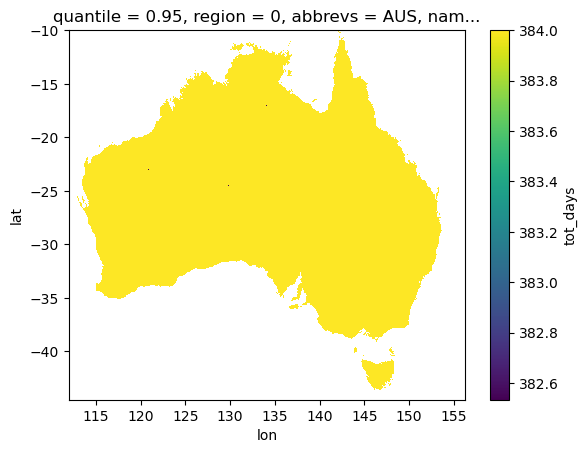

In [67]:
# check the model = 11 is correct for limit data for first period and nan for the other periods
Fdays1.sel(model=11).sum(dim='season',skipna=False).plot() 

## Start plotting

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/ffdi_change_sa_2090.png


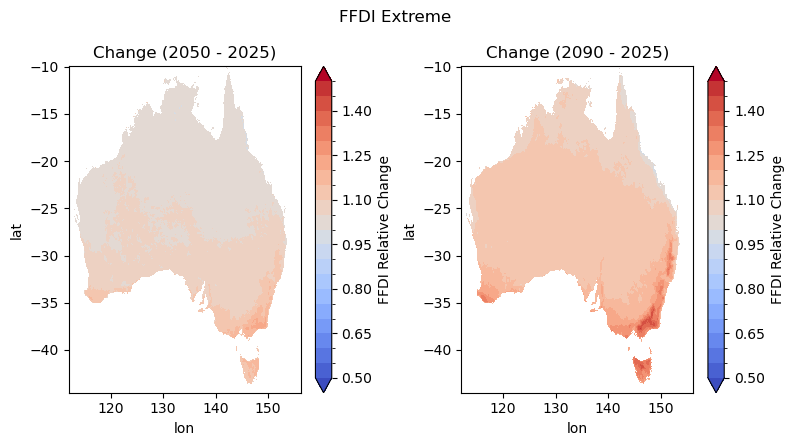

In [68]:
# plot FFDI extreme and relative error
plt.figure(figsize=(8,4.5))
    
plt.subplot(1,2,1)
lev = np.linspace(0.5, 1.5, 21)
cb2='coolwarm'
ax=(FM2/FM1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('Change (2050 - 2025)')
colorbar.set_label('FFDI Relative Change')
ax=plt.tight_layout()

lev = np.linspace(0.5, 1.5, 21)
plt.subplot(1,2,2)
cb2='coolwarm'
ax=(FM3/FM1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('Change (2090 - 2025)')
colorbar.set_label('FFDI Relative Change')

# Add global title
plt.suptitle('FFDI Extreme')
ax=plt.tight_layout()


fname=dirsave+'ffdi_change_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/ffdi_error_sa_2090.png


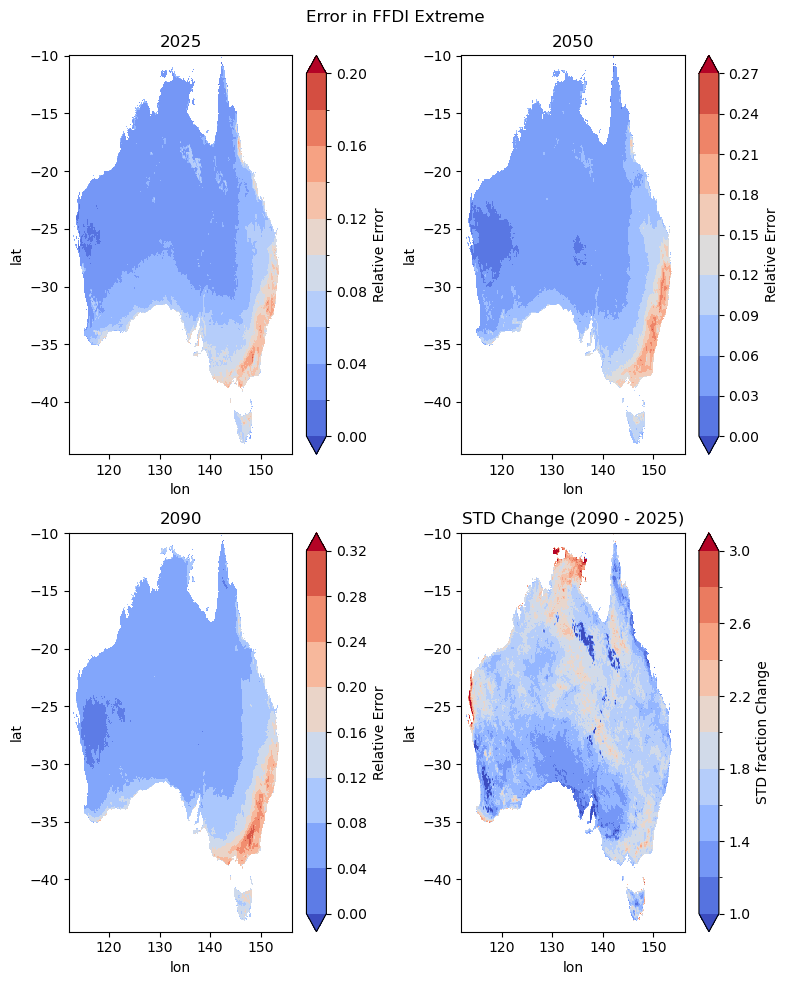

In [69]:
plt.figure(figsize=(8,10))
plt.subplot(2,2,1)
lev = np.linspace(0.0, 2, 11)
lev = 10
ax=(Rerr1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('2025')
colorbar.set_label('Relative Error')
ax=plt.tight_layout()

plt.subplot(2,2,2)
lev = np.linspace(0.0, 2, 11)
lev = 10
ax=(Rerr2).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('2050')
colorbar.set_label('Relative Error')
ax=plt.tight_layout()

plt.subplot(2,2,3)
lev = np.linspace(0.0, 2, 11)
lev = 10
ax=(Rerr3).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('2090')
colorbar.set_label('Relative Error')
ax=plt.tight_layout()

plt.subplot(2,2,4)
lev = np.linspace(1.0, 3, 11)
#lev = 10
ax=(Rerr3/Rerr1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('STD Change (2090 - 2025)')
colorbar.set_label('STD fraction Change')
# Add global title
plt.suptitle('Error in FFDI Extreme')
ax=plt.tight_layout()

fname=dirsave+'ffdi_error_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

def plot_4o(SM1,RE,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    mask = RE > 0.25

    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1); SM1.sel(season=id[0]).plot(levels=lev,cmap=cb,extend='max')
#    plt.contourf(RE.lon, RE.lat, mask.sel(season=id[0]), levels=[0.5, 1.5], colors='none',
#            hatches=['', '///'], alpha=.2)
#ax=plt.contourf(mask.lon, mask.lat, mask, levels=[0.5, 1.5], colors='none',
#            hatches=['...', ' '], alpha=0.4 )
# Change hatch color to white
#for collection in ax.collections[-2:]:
#    collection.set_edgecolor("white")
#    collection.set_facecolor("none")   # ensure no fill covers your plot
#    collection.set_linewidth(1.0)

    plt.title(id[0])
    
    plt.subplot(2,2,2); SM1.sel(season=id[1]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[1])
    plt.subplot(2,2,3); SM1.sel(season=id[2]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[2])
    plt.subplot(2,2,4); SM1.sel(season=id[3]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[3])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

In [70]:
## %%time
# variables storing seasonal number of days and mean values
# filter data based on relative error from multiple simulations
def filter(F):
    SM = F.mean(dim='model')
    SE = F.std(dim='model')
    RE = SE/(SM+1e-1)
    SF= SM.where(RE < .5)
    return SM,SF,RE

Sdays0,SFdays0,Rdays0= filter(Fdays0)
Smean0,SFmean0,Rmean0= filter(Fmean0)
Sdays1,SFdays1,Rdays1= filter(Fdays1)
Smean1,SFmean1,Rmean1= filter(Fmean1)
Sdays2,SFdays2,Rdays2= filter(Fdays2)
Smean2,SFmean2,Rmean2= filter(Fmean2)
Sdays3,SFdays3,Rdays3= filter(Fdays3)
Smean3,SFmean3,Rmean3= filter(Fmean3)


/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_DJF_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


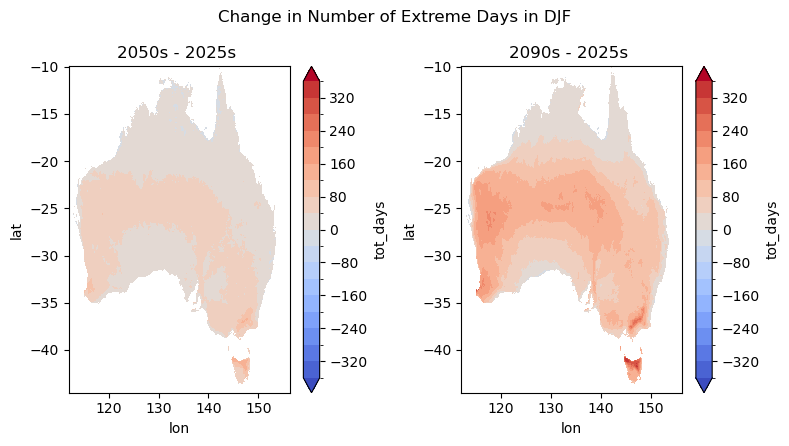

In [72]:
SM2=SFdays1
SM2=Sdays1
SM3=Sdays2
SM4=Sdays3
nvar=SM2.season.values
fname=dirsave+'change_DJF_days_'+dirstore+'.png'
lev = np.linspace(-360, 360, 19)
titl='Change in Number of Extreme Days in '
print(fname)
print(nvar)
plot_2(SM2,SM3,SM4,0,'season',nvar,lev, titl, fname)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_DJF_error_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


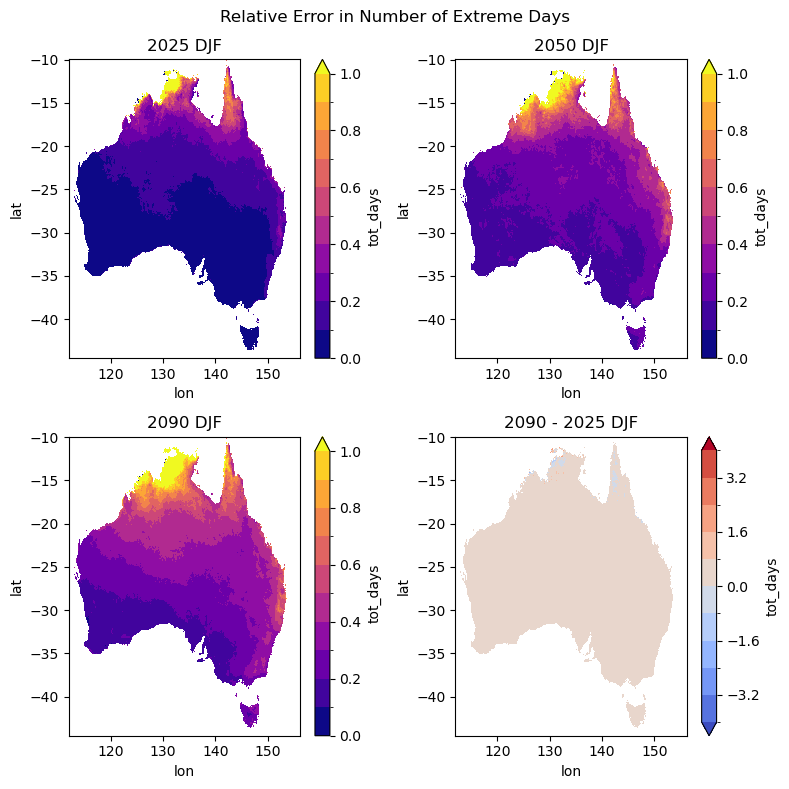

In [73]:
SM2=SFdays1
SM2=Rdays1
SM3=Rdays2
SM4=Rdays3
nvar=SM2.season.values
fname=dirsave+'change_DJF_error_'+dirstore+'.png'
lev = 21  #np.linspace(0, 360, 19)
lev =np.linspace(0, 1, 11)
titl='Relative Error in Number of Extreme Days'
print(fname)
print(nvar)
plot_4(SM2,SM3,SM4,0,'season',nvar,lev, titl, fname)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_SON_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


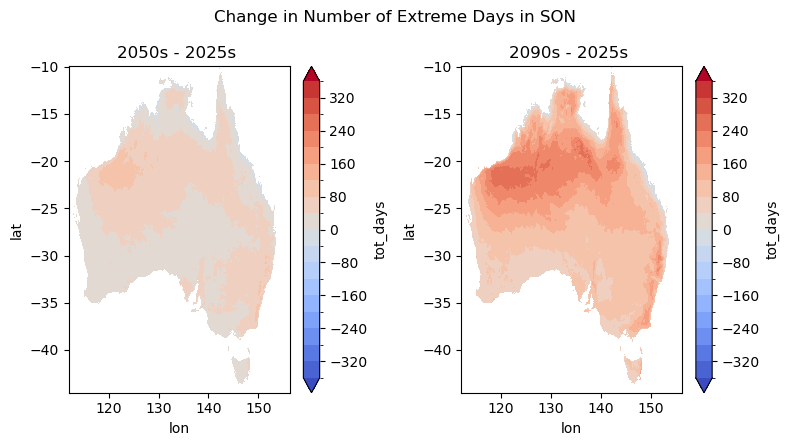

In [74]:
SM2=SFdays1
SM2=Sdays1
SM3=Sdays2
SM4=Sdays3
nvar=SM2.season.values
fname=dirsave+'change_SON_days_'+dirstore+'.png'
lev = np.linspace(-360, 360, 19)
titl='Change in Number of Extreme Days in '
print(fname)
print(nvar)
plot_2(SM2,SM3,SM4,3,'season',nvar,lev, titl, fname)

## Total change in number of days (contour 1.4 and 2)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_year_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


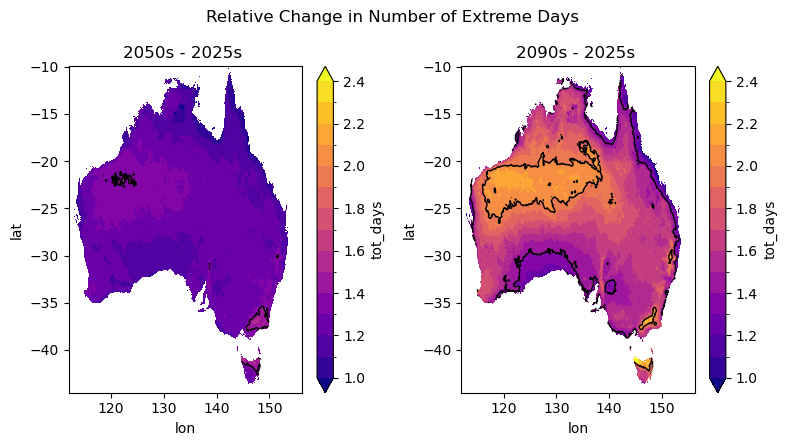

In [75]:
SM2=SFdays1
SM2=Sdays1
SM3=Sdays2
SM4=Sdays3
nvar=SM2.season.values
fname=dirsave+'change_year_days_'+dirstore+'.png'
lev = np.linspace(-2.4, 2.4, 13)
lev = np.linspace(1, 2.4, 15)
titl='Relative Change in Number of Extreme Days '
print(fname)
print(nvar)
plot_2a(SM2,SM3,SM4,3,'season',nvar,lev, titl, fname)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_SON_error_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


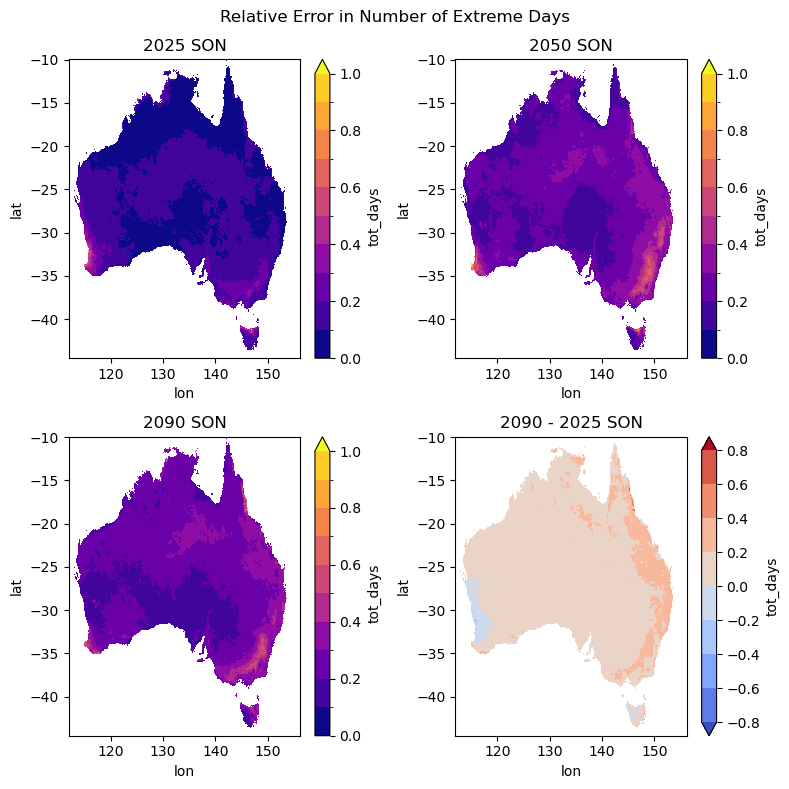

In [76]:
SM2=SFdays1
SM2=Rdays1
SM3=Rdays2
SM4=Rdays3
nvar=SM2.season.values
fname=dirsave+'change_SON_error_'+dirstore+'.png'
lev =np.linspace(0, 1, 11)
titl='Relative Error in Number of Extreme Days'
print(fname)
print(nvar)
plot_4(SM2,SM3,SM4,3,'season',nvar,lev, titl, fname)

## Trying to identify extreme RCMs

In [77]:
# function to find extreme models based on RMSE and mean deviation

def extreme(FD):
# Ensemble mean
    mean_field = FD.mean(dim="model")
# Deviation of each member from mean
    diff = FD - mean_field
# 1. RMSE (overall difference)
    rmse = np.sqrt((diff**2).mean(dim=("lat", "lon")))
# 2. Mean signed deviation (positive vs negative)
    mean_dev = diff.mean(dim=("lat", "lon"))
#### Find members with most positive and most negative mean deviation
    most_positive = mean_dev.argmax(dim="model").values
    most_negative = mean_dev.argmin(dim="model").values
    most_diff = rmse.argmax(dim='model').values

    print("\nModel most above mean (on average):", most_positive)
    print("Model most below mean (on average):", most_negative)
    print("Model most different:", most_diff,"rmse=",rmse.sel(model=most_diff).values)

# Sort by RMSE values along the "model" dimension
    rmse_sorted = rmse.sortby(rmse)
# Extract the sorted model IDs
    sorted_models = rmse["model"].sortby(rmse).values
    sorted_diff = mean_dev.sortby(rmse).values
# Print ranking
    print("Ranking of models (closest → farthest from mean):")
    for rank, (m, score,sc2) in enumerate(zip(sorted_models, rmse_sorted.values, sorted_diff), 1):
        print(f"{rank:2d}: Model {m}, RMSE = {score:.4f}, MD = {sc2:.6f}")
    return


In [95]:
#2090s
FD=Fdays3.sum(dim='season',skipna=False)
extreme(FD)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)



Model most above mean (on average): 20
Model most below mean (on average): 3
Model most different: 20 rmse= 480.55145984016747
Ranking of models (closest → farthest from mean):
 1: Model 18, RMSE = 56.5731, MD = 7.686150
 2: Model 12, RMSE = 65.1918, MD = -43.075772
 3: Model 14, RMSE = 71.4313, MD = -31.988667
 4: Model 13, RMSE = 75.9671, MD = -60.403899
 5: Model 15, RMSE = 77.6787, MD = 38.671569
 6: Model 21, RMSE = 85.1494, MD = -21.155852
 7: Model 2, RMSE = 93.8122, MD = -51.171044
 8: Model 9, RMSE = 96.9790, MD = -74.528379
 9: Model 10, RMSE = 111.0491, MD = -90.374992
10: Model 17, RMSE = 123.4974, MD = -101.030228
11: Model 1, RMSE = 129.9611, MD = -69.557308
12: Model 4, RMSE = 130.3320, MD = -96.414782
13: Model 7, RMSE = 160.2951, MD = -124.737370
14: Model 16, RMSE = 173.3189, MD = -151.930792
15: Model 0, RMSE = 186.9888, MD = 161.596590
16: Model 8, RMSE = 187.8198, MD = -168.282826
17: Model 19, RMSE = 201.0167, MD = 79.516690
18: Model 3, RMSE = 228.8422, MD = -20

/scratch/xv83/rxm599/sa_2020/model_12_ffdi_ex.nc


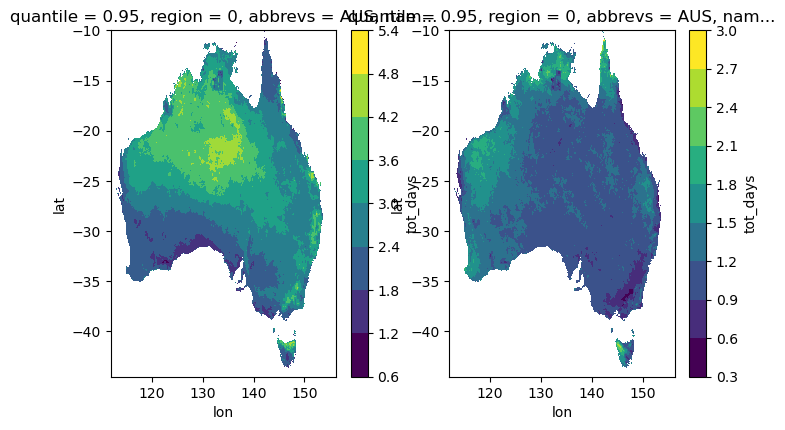

In [109]:
# two extremes

#(FD.sel(model=20)-FD.sel(model=3)).plot()
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1); (FD.sel(model=20)/365).plot(levels=10)
plt.subplot(1,2,2); (FD.sel(model=3)/365).plot(levels=10)
print(mfiles1[3])

In [83]:
# 2050s
FD=Fdays2.sum(dim='season',skipna=False)
extreme(FD)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)



Model most above mean (on average): 20
Model most below mean (on average): 2
Model most different: 20 rmse= 302.4300848733554
Ranking of models (closest → farthest from mean):
 1: Model 18, RMSE = 40.0948, MD = -8.499091
 2: Model 8, RMSE = 47.3957, MD = -20.700754
 3: Model 7, RMSE = 60.9684, MD = 22.065542
 4: Model 0, RMSE = 61.3857, MD = -34.425003
 5: Model 12, RMSE = 67.7060, MD = -54.468502
 6: Model 16, RMSE = 67.8841, MD = -36.787403
 7: Model 9, RMSE = 72.7053, MD = -54.926921
 8: Model 13, RMSE = 74.6164, MD = -65.492252
 9: Model 3, RMSE = 74.7441, MD = -56.467550
10: Model 17, RMSE = 77.1745, MD = -53.392908
11: Model 14, RMSE = 79.7259, MD = -64.352213
12: Model 21, RMSE = 79.8691, MD = -64.148541
13: Model 10, RMSE = 80.9929, MD = -61.112967
14: Model 19, RMSE = 87.3192, MD = -55.782583
15: Model 4, RMSE = 90.9786, MD = -69.795565
16: Model 2, RMSE = 98.2235, MD = -81.987021
17: Model 15, RMSE = 116.1703, MD = 105.291296
18: Model 1, RMSE = 118.8632, MD = 71.663425
19: 

In [85]:
# 2025s
FD=Fdays1.sum(dim='season',skipna=False)
extreme(FD)


Model most above mean (on average): 14
Model most below mean (on average): 12
Model most different: 12 rmse= 0.014238700191785254
Ranking of models (closest → farthest from mean):
 1: Model 14, RMSE = 0.0099, MD = 0.000044
 2: Model 16, RMSE = 0.0101, MD = 0.000040
 3: Model 2, RMSE = 0.0104, MD = 0.000033
 4: Model 3, RMSE = 0.0104, MD = 0.000033
 5: Model 9, RMSE = 0.0104, MD = 0.000033
 6: Model 17, RMSE = 0.0104, MD = 0.000033
 7: Model 0, RMSE = 0.0110, MD = 0.000019
 8: Model 8, RMSE = 0.0116, MD = 0.000004
 9: Model 10, RMSE = 0.0116, MD = 0.000004
10: Model 7, RMSE = 0.0117, MD = 0.000001
11: Model 1, RMSE = 0.0120, MD = -0.000006
12: Model 6, RMSE = 0.0123, MD = -0.000014
13: Model 5, RMSE = 0.0124, MD = -0.000017
14: Model 19, RMSE = 0.0124, MD = -0.000017
15: Model 4, RMSE = 0.0124, MD = -0.000017
16: Model 13, RMSE = 0.0125, MD = -0.000021
17: Model 15, RMSE = 0.0125, MD = -0.000021
18: Model 18, RMSE = 0.0125, MD = -0.000021
19: Model 21, RMSE = 0.0128, MD = -0.000028
20:

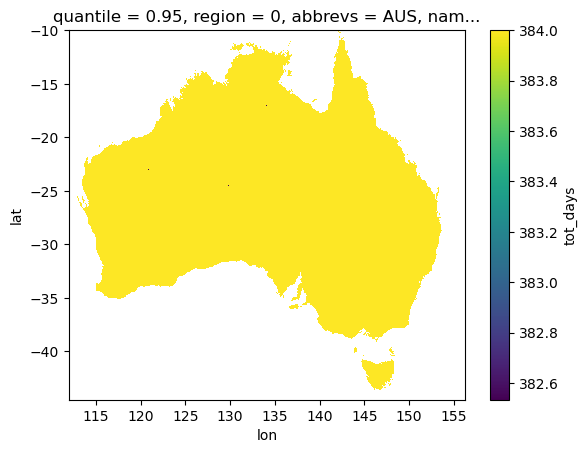

In [86]:
#Fdays1.sel(model=17).sum(dim='season').plot()
FD.sel(model=11).plot()

In [89]:
# 2025s
FD=Fmean3.mean(dim='season')
extreme(FD)


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)



Model most above mean (on average): 4
Model most below mean (on average): 19
Model most different: 19 rmse= 5.479099
Ranking of models (closest → farthest from mean):
 1: Model 15, RMSE = 1.5096, MD = -0.753554
 2: Model 17, RMSE = 1.5685, MD = -0.176739
 3: Model 0, RMSE = 1.6200, MD = 0.250771
 4: Model 12, RMSE = 2.1041, MD = 1.319224
 5: Model 9, RMSE = 2.1395, MD = -0.700537
 6: Model 2, RMSE = 2.1830, MD = -0.968261
 7: Model 10, RMSE = 2.1994, MD = -1.024694
 8: Model 13, RMSE = 2.2835, MD = 1.285299
 9: Model 8, RMSE = 2.3263, MD = -1.342056
10: Model 18, RMSE = 2.3859, MD = 1.311102
11: Model 3, RMSE = 2.6327, MD = -1.341749
12: Model 6, RMSE = 2.6689, MD = 1.317370
13: Model 16, RMSE = 2.9324, MD = -2.307800
14: Model 20, RMSE = 2.9461, MD = -0.630401
15: Model 7, RMSE = 2.9487, MD = -2.344234
16: Model 5, RMSE = 3.0009, MD = 1.470295
17: Model 21, RMSE = 3.5140, MD = 2.061136
18: Model 1, RMSE = 3.7216, MD = 0.193553
19: Model 14, RMSE = 3.7304, MD = 2.838609
20: Model 4, R

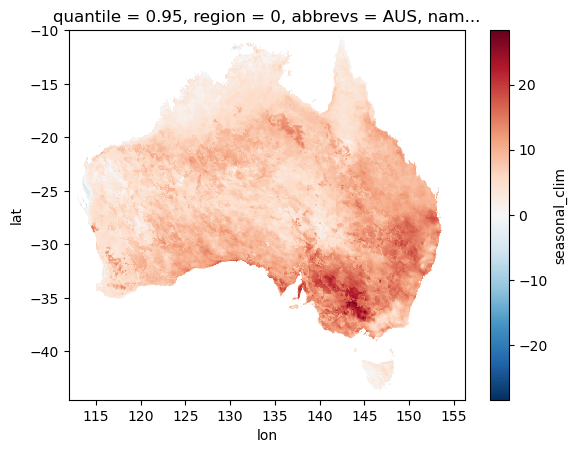

In [92]:
(FD.sel(model=4)-FD.sel(model=19)).plot()

##  Observations

In [14]:
FM=ds1.FFDI_mean.mean(dim='model')
FS=ds1.FFDI_mean.std(dim='model')
Rerr=FS/FM
Fdays=ds1.tot_days.mean(dim='model')
Fmean=ds1.seasonal_clim.mean(dim='model')

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/obs_ffdi_extreme_sa_2090.png


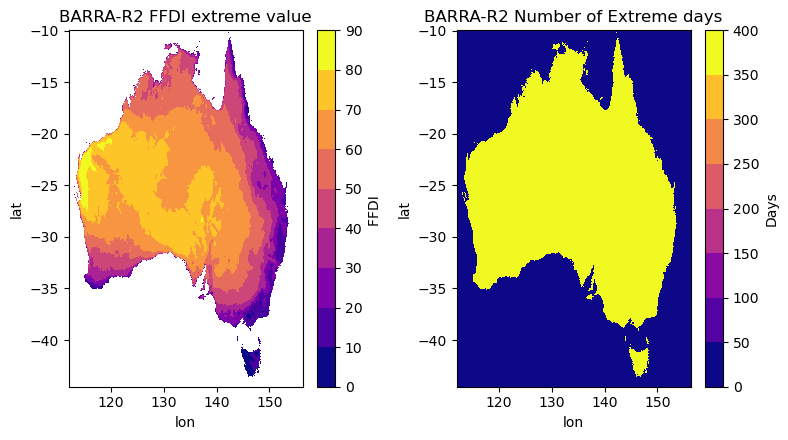

In [15]:
# plot FFDI extreme and relative error
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1)
ax=FM.plot(cmap='plasma',levels=10)
colorbar=ax.colorbar
ax=plt.title('BARRA-R2 FFDI extreme value')
colorbar.set_label('FFDI ')            

plt.subplot(1,2,2)
ax=Fdays.sum(dim='season').plot(cmap='plasma',levels=10)
colorbar=ax.colorbar
ax=plt.title('BARRA-R2 Number of Extreme days')
colorbar.set_label('Days')
ax=plt.tight_layout()


fname=dirsave+'obs_ffdi_extreme_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/obs_season_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


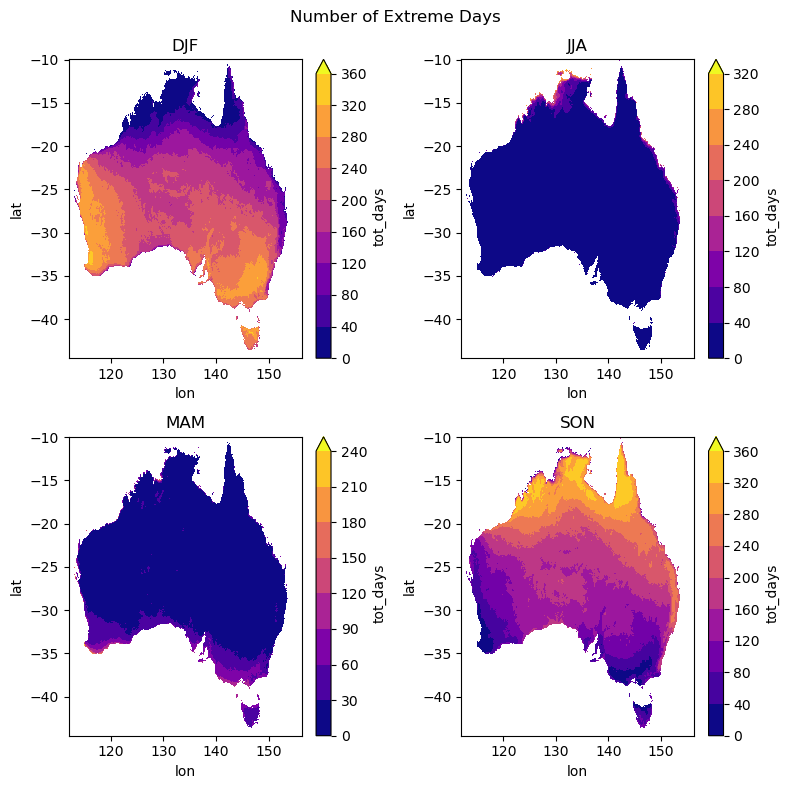

In [16]:
SM2=Fdays
#SM2=Fmean
nvar=SM2.season.values
fname=dirsave+'obs_season_days_'+dirstore+'.png'
lev = np.linspace(0, 360, 19)
lev=10
titl='Number of Extreme Days'
print(fname)
print(nvar)
plot_4o(SM2,Rerr,'season',nvar,lev, titl, fname)

In [17]:
ds2

<xarray.Dataset>
Dimensions:        (lat: 691, lon: 886, model: 22, season: 4)
Coordinates:
  * lat            (lat) float64 -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon            (lon) float64 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
    quantile       float64 0.95
    region         int64 0
    abbrevs        <U3 'AUS'
    names          <U9 'Australia'
  * season         (season) <U3 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: model
Data variables:
    FFDI_mean      (model, lat, lon) float64 dask.array<chunksize=(1, 691, 886), meta=np.ndarray>
    tot_days       (model, lat, lon, season) float64 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>
    seasonal_clim  (model, lat, lon, season) float32 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>